In [2]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import ttest_rel
%matplotlib inline


plt.rcParams['figure.figsize'] = (6.0, 6.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

plt.style.use('ggplot')

# autoreload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [3]:
try:
    lfs_data = pd.read_csv("src/data/lfs_data.csv")
except FileNotFoundError:
    print("Error: CSV file not found. Please make sure the file exists in the correct directory or provide the correct path.")
    exit()


#### Hyperparameter Tuning: LR

With our base parameters having been set, we can begin hyperparameter tuning. We'll implement *Random Search* as to not have to exhaustively branch through each possible combination of parameters. Below are the hyperparameter's we'll use and choose from. For example, if our algorithm randomly, for instance, chooses the second element of each, then it will test Logistic Regression at a learning rate of 0.1, batch size of 64, and the with the ADAM optimizer, etc. 

Values evenly spaced between 0.000001 and 0.001 will be explored for the learning rates. This will go on for fifty iterations, afterwhich a best model will be selected based on test accuracy. We'll perform random search rather than grid search, as a compromise to searching through all 259,200 combinations of hyperparameters in our grid.

In [4]:
from src.preprocessing import prepare_data_kfold

target_col = 'PUFC11_WORK'
feature_cols = [
    'PUFC05_AGE', 'PUFC06_MSTAT', 'PUFC04_SEX', 
    'PUFC07_GRADE', 'PUFC08_CURSCH', 
    'PUFC38_PREVJOB', 'PUFC31_FLWRK',
    'PUFC30_LOOKW', 'PUFC34_WYNOT'
]

categorical_cols = feature_cols
n_splits = 5
missing_value =-1
seed = 45

folds_data = prepare_data_kfold(lfs_data, target_col = target_col,
                         n_splits = n_splits,
                         missing_value = missing_value,
                         categorical_cols = categorical_cols,
                         feature_cols = feature_cols,
                         seed = seed)


Testing configuration:
{'weight_decay': np.float64(0.00046415888336127773), 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': np.float64(0.06951927961775606), 'batch_size': 256}

==================== FOLD 1 ====================
Epoch 1/30: Train Loss: 0.1188, Test Loss: 0.0772, Train Acc: 0.9775, Test Acc: 0.9857, LR: 0.069519
Epoch 2/30: Train Loss: 0.0729, Test Loss: 0.0712, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.069519
Epoch 3/30: Train Loss: 0.0693, Test Loss: 0.0693, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.069519
Epoch 4/30: Train Loss: 0.0678, Test Loss: 0.0684, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.069519
Epoch 5/30: Train Loss: 0.0670, Test Loss: 0.0679, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.062567
Epoch 6/30: Train Loss: 0.0665, Test Loss: 0.0677, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.062567
Epoch 7/30: Train Loss: 0.0662, Test Loss: 0.0674, Train Acc: 0.9862, Test Acc: 0.9857, LR: 0.0

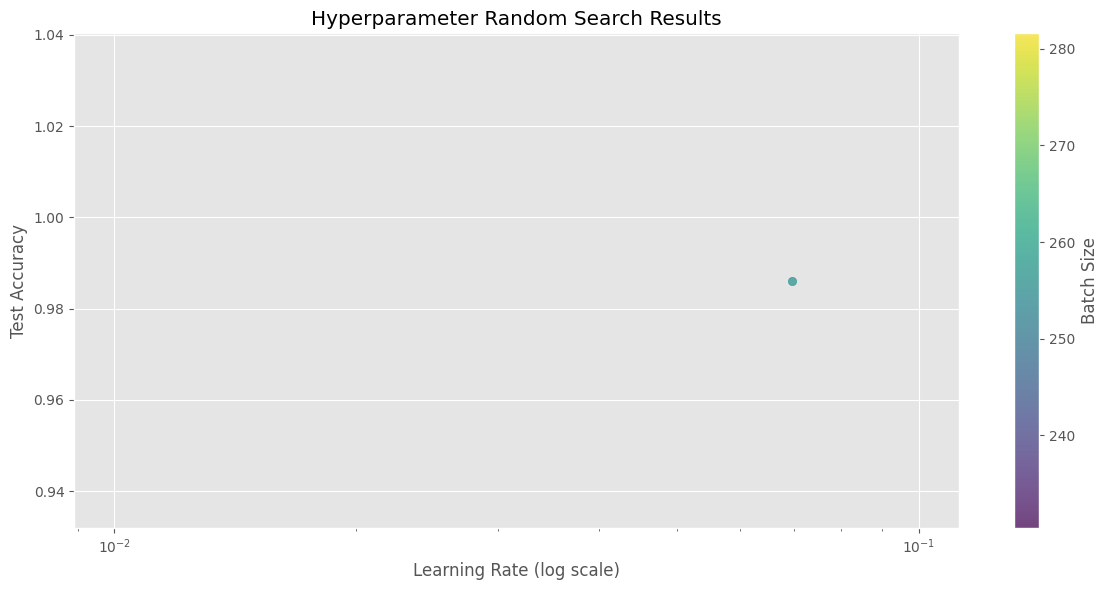


Top 5 Configurations:
   Learning Rate  Batch Size Optimizer  Test Accuracy  Test Loss  \
0       0.069519         256       sgd       0.986104   0.065669   

   Final Train Loss  Final Test Loss  Final Train Accuracy  \
0          0.065366         0.065669              0.986104   

   Final Test Accuracy  
0             0.986104  

Best Configuration:
Best Accuracy: 0.9861
Best Params: {'weight_decay': np.float64(0.00046415888336127773), 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': np.float64(0.06951927961775606), 'batch_size': 256}
Best Hyperparameters:
{'model': LogisticRegression(
  (linear): Linear(in_features=135, out_features=1, bias=True)
), 'best_params': {'weight_decay': np.float64(0.00046415888336127773), 'scheduler_step_size': 5, 'scheduler_gamma': 0.9, 'patience': 5, 'optimizer': 'sgd', 'num_epochs': 30, 'learning_rate': np.float64(0.06951927961775606), 'batch_size': 256}, 'results': [{'model': Log

In [5]:
from src.trainEvalLR import *
param_distributions = {
    'learning_rate': np.logspace(-4, -1, 20),
    'batch_size': [32, 64, 128, 256],
    'optimizer': ['sgd', 'adam', 'rmsprop'],
    'weight_decay': np.logspace(-5, -2, 10),
    'num_epochs': [30, 50, 75, 100],
    'scheduler_step_size': [5, 10, 15],
    'scheduler_gamma': [0.5, 0.7, 0.9],
    'patience': [3, 5, 7]
}

hyperparameter_results = hyperparameter_random_search(folds_data=folds_data, param_distributions=param_distributions, n_iter_search=1) 
lr_p_grid = hyperparameter_results
print("Best Hyperparameters:")
print(lr_p_grid)

#### Hyperparameter Tuning: DT

Similar to our methodology with Logistic Regression, we will implement random search for our tuning as a compromise to exhaustively searching through each hyperparameter combination. This time, we will explicitly define certain thresholds and measures. 

Our previous two hyperparameters, max_depth and minimum_impurity_decrease, will now range fom 30-60 and 0.001 to 0.1 respectively, adding variability to our parameters despite minimal signs of overfitting. We will allow the min_samples_leaf to enforce generalization or allow leaf nodes with one sample. 

Of note, we will add cost-complexity pruning as a form of regularizaton for our decision trees. We will also be exploring both gini and entropy as criteria, as the former minimizes chances of misclassification while the latter measures information gain.

In [1]:
from src.trainEvalDT import hyperparameter_random_search_dt
p_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [30, 45, 50, 60],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "min_impurity_decrease": [0.001, 0.005, 0.01], ## pre-pruning
    "ccp_alpha": np.logspace(-4, 0, 10) ## post-pruning
}

dt_p_grid = hyperparameter_random_search_dt(folds_data=folds_data, p_grid=p_grid, n_iter_search = 1)

NameError: name 'np' is not defined

#### Hyperparameter Tuning: kNN

To optimize the kNN model's performance, we conduct hyperparameter tuning using random search. The goal is to identify the combination of hyperparameters that yields the highest accuracy. Key parameters include:

n_neighbors being the number of neighbors considered during classification. Smaller values increase sensitivity to noise, while larger values smoothen the decision boundary,

weights being the weighting scheme applied to the neighbors, either uniform (equal influence) or distance (closer neighbors have more influence), and

p being the distance metric, where p=1 uses Manhattan distance and p=2 uses Euclidean distance.

In [ ]:

from src.trainEvalKNN import hyperparameter_random_search_knn
p_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2], 
}

knn_p_grid = hyperparameter_random_search_knn(folds_data, p_grid, n_iter_search=1)


Testing configuration:
{'weights': 'uniform', 'p': 1, 'n_neighbors': 9}
